# JurisFair BNPL Credit Monitor — Final Quantitative Analysis Notebook

**Task 3 Option C: Analytical Design with Quantitative Component**

**Hypothetical RegTech provider:** AxisReg Analytics

**Use case:** Klarna-style BNPL / consumer credit decisions in the US and EU

**Domain:** credit scoring, algorithmic fairness, fair lending, and AI governance



In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display, Image
from sklearn.metrics import roc_auc_score, brier_score_loss


def find_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / 'src').exists() and (cwd / 'configs').exists():
        return cwd
    if (cwd.parent / 'src').exists() and (cwd.parent / 'configs').exists():
        return cwd.parent
    raise RuntimeError('Could not locate project root. Run from project root or notebooks/.')


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'jurisdiction_rules.yaml'
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'

for directory in [DATA_DIR, OUTPUTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))

from generate_synthetic_data import FEATURE_COLUMNS, generate_synthetic_data
from train_credit_model import (
    train_credit_model,
    score_with_existing_model,
    apply_approval_decision,
    generate_denial_reasons,
    audit_denial_reason_coverage,
)
from fairness_metrics import (
    compute_raad,
    compute_air,
    compute_fnr_gap,
    compute_drift_metrics,
    compute_audit_group_missingness,
)
from jurisdiction_engine import load_jurisdiction_rules, apply_jurisdiction_rules
from sensitivity_analysis import run_all_scenarios

RANDOM_SEED = 42
APPROVAL_CUTOFF = 0.18

print('Project root:', PROJECT_ROOT)
print('Using config:', CONFIG_PATH)

## 2. Load jurisdiction rules

The tool has a jurisdiction configuration layer.

- Thresholds are applied to **`|RAAD|`**, not raw RAAD. The sign is retained only to identify which audit group is adversely affected.
- AIR is treated as a screening trigger. AIR does not decide illegality, but it prevents a contradictory “green” output when outcome disparity is severe.
- Audit-group missingness above the configured threshold is treated as an insufficient-evidence / data-governance issue.
- EU PSI is not treated as a fairness metric by itself. If PSI exceeds threshold, the tool decomposes drift by subgroup and reassesses fairness impact.
- Denial reasons are used in both jurisdictions, but for different purposes: US adverse-action specificity; EU traceability, auditability, technical documentation, and human oversight.

In [ ]:
rules = load_jurisdiction_rules(CONFIG_PATH)

summary_rows = []
for j in ['US', 'EU']:
    cfg = rules[j]
    row = {
        'jurisdiction': j,
        'raad_amber_threshold': cfg['raad_amber_threshold'],
        'raad_red_threshold': cfg['raad_red_threshold'],
        'primary_metric': cfg.get('primary_metric'),
        'regulatory_focus': '; '.join(cfg.get('regulatory_focus', [])),
    }
    summary_rows.append(row)

rule_summary = pd.DataFrame(summary_rows)
display(rule_summary)

## 3. Generate synthetic BNPL application data

The dataset has 20,000 synthetic applications: 10,000 US and 10,000 EU. Each record represents a BNPL / consumer credit application.

The audit group is only used for compliance monitoring and is excluded from model training. However, some credit variables are correlated with audit-group membership. This simulates proxy-risk conditions: the model does not directly use the audit group, but model inputs and residual policy rules may still produce unequal outcomes.

In [3]:
raw_df = generate_synthetic_data(n_us=10_000, n_eu=10_000, scenario='baseline', random_seed=RANDOM_SEED)

print(f'Total applications: {len(raw_df):,}')
print('\nJurisdiction distribution:')
print(raw_df['jurisdiction'].value_counts())
print('\nAudit-group distribution:')
print(raw_df['audit_group'].value_counts())

key_profile = raw_df.groupby('audit_group')[[
    'income',
    'debt_to_income_ratio',
    'credit_history_length_months',
    'thin_file_flag',
    'repayment_history_score',
    'legacy_bureau_score',
]].mean().round(3)

display(key_profile)
display(raw_df.head())

Total applications: 20,000

Jurisdiction distribution:
jurisdiction
US    10000
EU    10000
Name: count, dtype: int64

Audit-group distribution:
audit_group
reference_group                  11109
protected_or_vulnerable_group     8891
Name: count, dtype: int64


,income,debt_to_income_ratio,credit_history_length_months,thin_file_flag,repayment_history_score,legacy_bureau_score
audit_group,,,,,,
protected_or_vulnerable_group,40241.326,0.419,33.882,0.420,0.581,0.421
reference_group,40562.729,0.341,44.402,0.157,0.698,0.616


,applicant_id,jurisdiction,audit_group,income,debt_to_income_ratio,credit_history_length_months,prior_late_payments,existing_klarna_balance,purchase_amount,merchant_category_risk,thin_file_flag,device_consistency_score,repayment_history_score,legacy_bureau_score,true_pd,actual_default_90d
0,US-00001,US,protected_or_vulnerable_group,15560.675657,0.326404,27.457482,2.0,754.715092,76.717315,0.878563,0.0,0.706749,0.207049,0.360721,0.216569,1
1,US-00002,US,reference_group,60398.227004,0.379886,25.426500,0.0,85.416007,232.048632,0.810769,0.0,0.421940,0.787912,0.605896,0.027555,0
2,US-00003,US,protected_or_vulnerable_group,61835.084167,0.505895,9.397257,0.0,1036.726002,264.815835,0.985105,0.0,0.554673,0.645138,0.120088,0.079889,0
3,US-00004,US,protected_or_vulnerable_group,29334.950487,0.448628,22.428436,2.0,265.051994,143.655179,0.395368,0.0,0.888693,0.546040,0.383314,0.130963,0
4,US-00005,US,reference_group,45916.241038,0.354362,16.580969,1.0,1224.841204,451.611964,0.211626,0.0,0.919623,0.665446,0.508369,0.089838,0


## 4. Train baseline credit risk model

The prototype uses logistic regression because it is simple, interpretable, and suitable for a compliance demonstration. The model predicts `actual_default_90d`. The following variables are excluded from model training:

- `audit_group`
- `jurisdiction`
- `approved`
- denial reason columns

This keeps the audit group out of the credit decisioning model while allowing downstream monitoring of disparate outcomes.

In [4]:
model, scaler, scored_df = train_credit_model(raw_df, random_seed=RANDOM_SEED)

auc = roc_auc_score(scored_df['actual_default_90d'], scored_df['predicted_pd'])
brier = brier_score_loss(scored_df['actual_default_90d'], scored_df['predicted_pd'])

print('Model features:')
print(FEATURE_COLUMNS)
print(f'Actual default rate: {scored_df["actual_default_90d"].mean():.4f}')
print(f'Mean predicted PD: {scored_df["predicted_pd"].mean():.4f}')
print(f'AUC: {auc:.4f}')
print(f'Brier score: {brier:.4f}')

Model features:
['income', 'debt_to_income_ratio', 'credit_history_length_months', 'prior_late_payments', 'existing_klarna_balance', 'purchase_amount', 'merchant_category_risk', 'thin_file_flag', 'device_consistency_score', 'repayment_history_score']
Actual default rate: 0.1006
Mean predicted PD: 0.1006
AUC: 0.6528
Brier score: 0.0874


## 5. Apply approval decision and generate denial reasons

The approval rule uses a unified baseline cutoff: approve if `effective_pd <= 0.18`. `effective_pd` combines the model-predicted default probability with a residual policy layer. This simulates a realistic setting where production credit decisions may still include legacy bureau and policy rules.

denial reasons are mapped to both model features and policy-layer drivers. This avoids claiming 100% reason coverage while omitting a real approval driver such as `legacy_bureau_score`.

In [5]:
processed_df = apply_approval_decision(scored_df, cutoff=APPROVAL_CUTOFF)
processed_df = generate_denial_reasons(processed_df, model, scaler)

print(f'Overall approval rate: {processed_df["approved"].mean():.3f}')
print('\nApproval rate by jurisdiction and audit group:')
approval_by_group = processed_df.pivot_table(
    index='jurisdiction', columns='audit_group', values='approved', aggfunc='mean'
).round(3)
display(approval_by_group)

reason_audit = audit_denial_reason_coverage(processed_df)
print('\nDenial reason coverage audit:', reason_audit)
print('\nTop denial reason 1 codes:')
display(processed_df.loc[processed_df['approved'] == 0, 'denial_reason_1'].value_counts().head(10).to_frame('count'))

Overall approval rate: 0.830

Approval rate by jurisdiction and audit group:


audit_group,protected_or_vulnerable_group,reference_group
jurisdiction,,
EU,0.674,0.956
US,0.665,0.959



Denial reason coverage audit: {'coverage_rate': 1.0, 'vague_reason_count': 0}

Top denial reason 1 codes:


,count
denial_reason_1,
LOW_LEGACY_BUREAU_SCORE,1960
THIN_CREDIT_FILE,1132
PRIOR_LATE_PAYMENTS,209
DEVICE_INCONSISTENCY,100
WEAK_REPAYMENT_HISTORY,4
ELEVATED_MERCHANT_RISK,2


## 6. Compute RAAD: Risk-Adjusted Approval Disparity

RAAD compares approval outcomes within comparable risk bands.

For each predicted-PD risk band:

`Gap_b = approval_rate(reference_group, b) - approval_rate(protected_or_vulnerable_group, b)`

The RAAD is a weighted average of valid-band gaps. Alerting uses **`|RAAD|`**. The sign is retained only to identify which audit group is adversely affected.

Interpretation:

- `RAAD > 0`: protected / vulnerable group has lower approval after risk adjustment.
- `RAAD < 0`: reference group has lower approval after risk adjustment.
- Both directions are monitored.
- RAAD is a review trigger, not an automatic legal conclusion.

In [6]:
raad_rows = []
band_tables = {}

for jurisdiction in ['US', 'EU']:
    sub = processed_df.loc[processed_df['jurisdiction'] == jurisdiction].copy()
    result = compute_raad(sub, random_seed=RANDOM_SEED)
    raad_rows.append({
        'jurisdiction': jurisdiction,
        'raad': result.raad,
        'abs_raad': result.abs_raad,
        'ci_95': f'[{result.ci_lower:.3f}, {result.ci_upper:.3f}]',
        'affected_group': result.affected_group,
        'n_bands_used': result.n_bands_used,
    })
    band_tables[jurisdiction] = pd.DataFrame(result.band_results)

raad_summary = pd.DataFrame(raad_rows)
display(raad_summary)

print('US risk-band details:')
display(band_tables['US'])
print('EU risk-band details:')
display(band_tables['EU'])

,jurisdiction,raad,abs_raad,ci_95,affected_group,n_bands_used
0,US,0.042048,0.042048,"[0.034, 0.050]",protected_or_vulnerable_group,10
1,EU,0.043888,0.043888,"[0.034, 0.050]",protected_or_vulnerable_group,10


US risk-band details:


,risk_band,reference_approval_rate,protected_approval_rate,gap,weight,n_reference,n_protected
0,band_1,1.000000,1.000000,0.000000,0.1,888,112
1,band_2,1.000000,1.000000,0.000000,0.1,821,179
2,band_3,1.000000,1.000000,0.000000,0.1,768,232
3,band_4,1.000000,1.000000,0.000000,0.1,717,283
4,band_5,1.000000,1.000000,0.000000,0.1,621,379
5,band_6,1.000000,1.000000,0.000000,0.1,533,467
6,band_7,1.000000,1.000000,0.000000,0.1,457,543
7,band_8,0.994366,0.913178,0.081188,0.1,355,645
8,band_9,0.593220,0.253927,0.339294,0.1,236,764
9,band_10,0.000000,0.000000,0.000000,0.1,129,871


EU risk-band details:


,risk_band,reference_approval_rate,protected_approval_rate,gap,weight,n_reference,n_protected
0,band_1,1.000000,1.000000,0.000000,0.1,917,83
1,band_2,1.000000,1.000000,0.000000,0.1,831,169
2,band_3,1.000000,1.000000,0.000000,0.1,764,236
3,band_4,1.000000,1.000000,0.000000,0.1,694,306
4,band_5,1.000000,1.000000,0.000000,0.1,634,366
5,band_6,1.000000,1.000000,0.000000,0.1,504,496
6,band_7,1.000000,1.000000,0.000000,0.1,475,525
7,band_8,0.994521,0.948031,0.046489,0.1,365,635
8,band_9,0.635628,0.256308,0.379319,0.1,247,753
9,band_10,0.013072,0.000000,0.013072,0.1,153,847


## 7. Compute auxiliary monitoring metrics

RAAD is the primary metric. The tool also uses supporting metrics:

- AIR: adverse impact ratio, used as a screening trigger.
- FNR gap: error-rate gap among non-defaulters.
- PSI: data drift trigger, not a fairness proof.
- Subgroup PSI gap: checks whether drift is concentrated in one audit group.
- Audit-group missingness: checks whether the tool has sufficient evidence to monitor fairness.

In [7]:
aux_rows = []
for jurisdiction in ['US', 'EU']:
    sub = processed_df.loc[processed_df['jurisdiction'] == jurisdiction].copy()
    baseline_sub = processed_df.loc[processed_df['jurisdiction'] == jurisdiction].copy()
    drift = compute_drift_metrics(baseline_sub, sub)
    aux_rows.append({
        'jurisdiction': jurisdiction,
        'air': compute_air(sub),
        'fnr_gap': compute_fnr_gap(sub),
        'overall_psi': drift['overall_psi'],
        'reference_subgroup_psi': drift['reference_subgroup_psi'],
        'protected_subgroup_psi': drift['protected_subgroup_psi'],
        'subgroup_psi_gap': drift['subgroup_psi_gap'],
        'audit_group_missingness': compute_audit_group_missingness(sub),
    })

aux_metrics = pd.DataFrame(aux_rows)
display(aux_metrics.round(4))

,jurisdiction,air,fnr_gap,overall_psi,reference_subgroup_psi,protected_subgroup_psi,subgroup_psi_gap,audit_group_missingness
0,US,0.6940,-0.2769,0.0,0.0,0.0,0.0,0.0
1,EU,0.7046,-0.2599,0.0,0.0,0.0,0.0,0.0


## 8. Apply US and EU jurisdiction-specific rule engine

The same quantitative signals are passed through US and EU configurations.

US mode focuses on fair lending monitoring, adverse-action reason specificity, AI credit-decision explainability, and fair-access / unlawful debanking review. Statistical disparity is not labelled as an automatic ECOA violation.

EU mode treats creditworthiness / credit-scoring AI as a high-risk AI governance problem. It applies stricter RAAD thresholds and uses drift, subgroup drift, reason mapping, and traceability as governance controls.

In [8]:
baseline_rows = []
for jurisdiction in ['US', 'EU']:
    sub = processed_df.loc[processed_df['jurisdiction'] == jurisdiction].copy()
    baseline_sub = processed_df.loc[processed_df['jurisdiction'] == jurisdiction].copy()
    raad_result = compute_raad(sub, random_seed=RANDOM_SEED)
    drift = compute_drift_metrics(baseline_sub, sub)
    reason_audit_sub = audit_denial_reason_coverage(sub)

    rule_output = apply_jurisdiction_rules(
        jurisdiction=jurisdiction,
        raad_result=raad_result,
        air=compute_air(sub),
        overall_psi=drift['overall_psi'],
        subgroup_psi_gap=drift['subgroup_psi_gap'],
        audit_group_missingness=compute_audit_group_missingness(sub),
        reason_coverage_rate=reason_audit_sub['coverage_rate'],
        rules=rules,
        config_applied=jurisdiction,
    )

    baseline_rows.append({
        **rule_output,
        'ci_95': f'[{raad_result.ci_lower:.3f}, {raad_result.ci_upper:.3f}]',
        'n_applications': len(sub),
        'fnr_gap': compute_fnr_gap(sub),
    })

manual_baseline_results = pd.DataFrame(baseline_rows)
display(manual_baseline_results[[
    'jurisdiction', 'status', 'raad', 'abs_raad', 'ci_95', 'air', 'overall_psi',
    'subgroup_psi_gap', 'affected_group', 'human_review_required', 'triggers',
    'regulatory_interpretation'
]])

,jurisdiction,status,raad,abs_raad,ci_95,air,overall_psi,subgroup_psi_gap,affected_group,human_review_required,triggers,regulatory_interpretation
0,US,watch,0.042048,0.042048,"[0.034, 0.050]",0.693988,0.0,0.0,protected_or_vulnerable_group,True,AIR=0.694 below screening threshold (0.8),US fair lending monitoring — Not an automatic ...
1,EU,amber,0.043888,0.043888,"[0.034, 0.050]",0.704574,0.0,0.0,protected_or_vulnerable_group,True,|RAAD|=0.044 exceeds amber threshold (0.03); A...,EU high-risk AI governance — High-risk AI bias...


## 9. Run full fixed-model sensitivity analysis

This project uses a fixed baseline model and scaler for sensitivity analysis. This is more consistent with production monitoring: the approved baseline model is tested against stressed or shifted current-period data, instead of retraining a new model in every scenario.

Scenarios:

1. Baseline
2. Economic stress
3. Distribution shift
4. Credit tightening
5. Missing audit-group data at 10%, 20%, and 30%
6. Jurisdictional misconfiguration

In [9]:
baseline_data, baseline_results, sensitivity_results, jurisdiction_flags = run_all_scenarios(
    CONFIG_PATH, random_seed=RANDOM_SEED
)

print('Baseline results from full pipeline:')
display(baseline_results[[
    'jurisdiction', 'status', 'raad', 'abs_raad', 'ci_95', 'air',
    'overall_psi', 'subgroup_psi_gap', 'affected_group', 'triggers'
]])

print('Sensitivity results:')
display(sensitivity_results[[
    'scenario', 'jurisdiction', 'config_applied', 'status', 'abs_raad',
    'air', 'overall_psi', 'subgroup_psi_gap', 'audit_group_missingness',
    'affected_group', 'triggers'
]])

Baseline results from full pipeline:


,jurisdiction,status,raad,abs_raad,ci_95,air,overall_psi,subgroup_psi_gap,affected_group,triggers
0,US,watch,0.042048,0.042048,"[0.034, 0.050]",0.693988,0.0,0.0,protected_or_vulnerable_group,AIR=0.694 below screening threshold (0.8)
1,EU,amber,0.043888,0.043888,"[0.034, 0.050]",0.704574,0.0,0.0,protected_or_vulnerable_group,|RAAD|=0.044 exceeds amber threshold (0.03); A...


Sensitivity results:


,scenario,jurisdiction,config_applied,status,abs_raad,air,overall_psi,subgroup_psi_gap,audit_group_missingness,affected_group,triggers
0,economic_stress,US,US,amber,0.054435,0.600352,0.157382,0.110938,0.0000,protected_or_vulnerable_group,|RAAD|=0.054 exceeds amber threshold (0.05); A...
1,economic_stress,EU,EU,amber,0.046588,0.581656,0.175620,0.090646,0.0000,protected_or_vulnerable_group,|RAAD|=0.047 exceeds amber threshold (0.03); A...
2,distribution_shift,US,US,watch,0.041716,0.623706,0.010596,0.028301,0.0000,protected_or_vulnerable_group,AIR=0.624 below screening threshold (0.8)
3,distribution_shift,EU,EU,red,0.056680,0.601645,0.017657,0.046549,0.0000,protected_or_vulnerable_group,|RAAD|=0.057 exceeds amber threshold (0.03); |...
4,credit_tightening,US,US,amber,0.061710,0.477857,0.000000,0.000000,0.0000,protected_or_vulnerable_group,|RAAD|=0.062 exceeds amber threshold (0.05); A...
5,credit_tightening,EU,EU,red,0.062699,0.494012,0.000000,0.000000,0.0000,protected_or_vulnerable_group,|RAAD|=0.063 exceeds amber threshold (0.03); |...
6,missing_audit_10pct,US,US,amber,0.042284,0.692871,0.000000,0.000091,0.1036,protected_or_vulnerable_group,AIR=0.693 below screening threshold (0.8); Aud...
7,missing_audit_10pct,EU,EU,amber,0.045100,0.706391,0.000000,0.000318,0.0964,protected_or_vulnerable_group,|RAAD|=0.045 exceeds amber threshold (0.03); A...
8,missing_audit_20pct,US,US,amber,0.044505,0.692710,0.000000,0.000135,0.2041,protected_or_vulnerable_group,AIR=0.693 below screening threshold (0.8); Aud...
9,missing_audit_20pct,EU,EU,amber,0.045510,0.701363,0.000000,0.000229,0.1959,protected_or_vulnerable_group,|RAAD|=0.046 exceeds amber threshold (0.03); A...


## 10. Visualisations

The visualisation design avoids placing RAAD, AIR, and PSI on one axis because these metrics have different scales and interpretations. Each metric family is plotted separately.

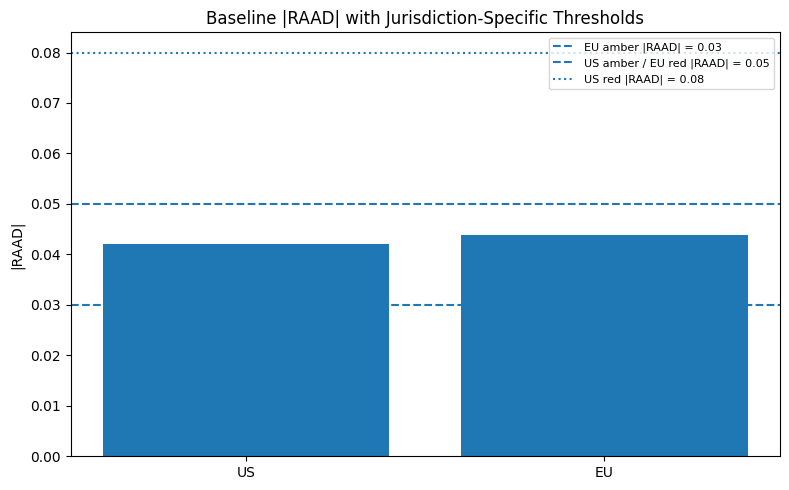

In [10]:
def plot_baseline_abs_raad(baseline_results: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(baseline_results['jurisdiction'], baseline_results['abs_raad'])
    ax.axhline(0.03, linestyle='--', label='EU amber |RAAD| = 0.03')
    ax.axhline(0.05, linestyle='--', label='US amber / EU red |RAAD| = 0.05')
    ax.axhline(0.08, linestyle=':', label='US red |RAAD| = 0.08')
    ax.set_ylabel('|RAAD|')
    ax.set_title('Baseline |RAAD| with Jurisdiction-Specific Thresholds')
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

fig = plot_baseline_abs_raad(baseline_results)
fig.savefig(FIGURES_DIR / 'baseline_abs_raad_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

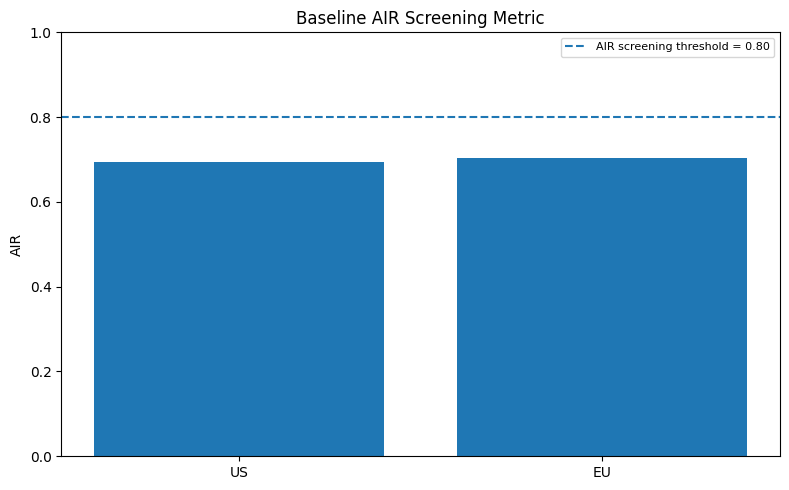

In [11]:
def plot_baseline_air(baseline_results: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(baseline_results['jurisdiction'], baseline_results['air'])
    ax.axhline(0.80, linestyle='--', label='AIR screening threshold = 0.80')
    ax.set_ylabel('AIR')
    ax.set_title('Baseline AIR Screening Metric')
    ax.set_ylim(0, max(1.0, baseline_results['air'].max() + 0.1))
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

fig = plot_baseline_air(baseline_results)
fig.savefig(FIGURES_DIR / 'baseline_air_screening.png', dpi=150, bbox_inches='tight')
plt.show()

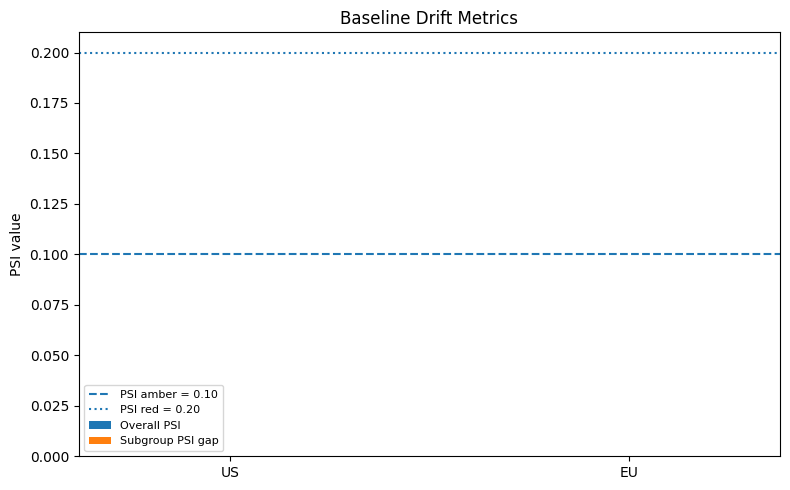

In [12]:
def plot_baseline_psi(baseline_results: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(baseline_results))
    ax.bar(x - 0.15, baseline_results['overall_psi'], width=0.3, label='Overall PSI')
    ax.bar(x + 0.15, baseline_results['subgroup_psi_gap'], width=0.3, label='Subgroup PSI gap')
    ax.axhline(0.10, linestyle='--', label='PSI amber = 0.10')
    ax.axhline(0.20, linestyle=':', label='PSI red = 0.20')
    ax.set_xticks(x)
    ax.set_xticklabels(baseline_results['jurisdiction'])
    ax.set_ylabel('PSI value')
    ax.set_title('Baseline Drift Metrics')
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

fig = plot_baseline_psi(baseline_results)
fig.savefig(FIGURES_DIR / 'baseline_psi_drift.png', dpi=150, bbox_inches='tight')
plt.show()

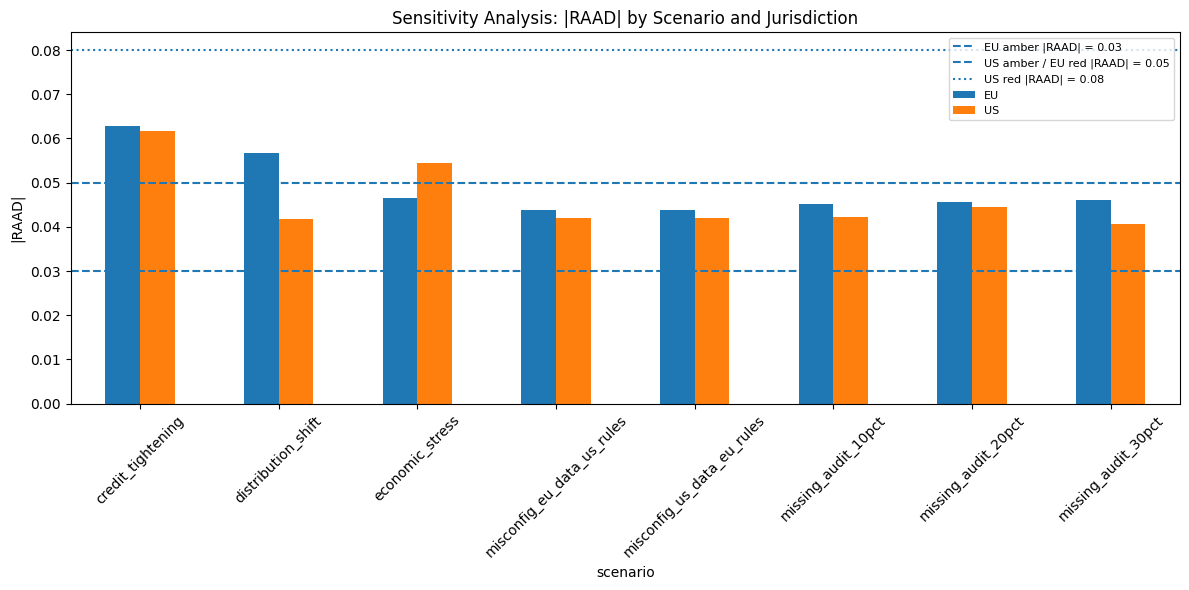

In [13]:
def plot_sensitivity_abs_raad(sensitivity_results: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot = sensitivity_results.pivot_table(
        index='scenario', columns='jurisdiction', values='abs_raad', aggfunc='first'
    )
    pivot.plot(kind='bar', ax=ax)
    ax.axhline(0.03, linestyle='--', label='EU amber |RAAD| = 0.03')
    ax.axhline(0.05, linestyle='--', label='US amber / EU red |RAAD| = 0.05')
    ax.axhline(0.08, linestyle=':', label='US red |RAAD| = 0.08')
    ax.set_ylabel('|RAAD|')
    ax.set_title('Sensitivity Analysis: |RAAD| by Scenario and Jurisdiction')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

fig = plot_sensitivity_abs_raad(sensitivity_results)
fig.savefig(FIGURES_DIR / 'sensitivity_abs_raad.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Export outputs

These files are used directly in the report:

- `data/synthetic_bnpl_applications.csv`
- `outputs/baseline_results.csv`
- `outputs/sensitivity_results.csv`
- `outputs/jurisdiction_flags.csv`
- `outputs/figures/*.png`

In [14]:
processed_df.to_csv(DATA_DIR / 'synthetic_bnpl_applications.csv', index=False)
baseline_results.to_csv(OUTPUTS_DIR / 'baseline_results.csv', index=False)
sensitivity_results.to_csv(OUTPUTS_DIR / 'sensitivity_results.csv', index=False)
jurisdiction_flags.to_csv(OUTPUTS_DIR / 'jurisdiction_flags.csv', index=False)

print('Exported files:')
for path in [
    DATA_DIR / 'synthetic_bnpl_applications.csv',
    OUTPUTS_DIR / 'baseline_results.csv',
    OUTPUTS_DIR / 'sensitivity_results.csv',
    OUTPUTS_DIR / 'jurisdiction_flags.csv',
]:
    print('-', path.relative_to(PROJECT_ROOT))

print('\nFigures:')
for path in sorted(FIGURES_DIR.glob('*.png')):
    print('-', path.relative_to(PROJECT_ROOT))

Exported files:
- data/synthetic_bnpl_applications.csv
- outputs/baseline_results.csv
- outputs/sensitivity_results.csv
- outputs/jurisdiction_flags.csv

Figures:
- outputs/figures/baseline_abs_raad_thresholds.png
- outputs/figures/baseline_air_screening.png
- outputs/figures/baseline_psi_drift.png
- outputs/figures/sensitivity_abs_raad.png


## 12. Interpretation for the report


1. **The tool is genuinely jurisdiction-aware.** The same approximate level of `|RAAD|` can produce different outputs under US and EU thresholds. US mode treats statistical disparity as a fair-lending monitoring and explanation-review trigger, not an automatic legal violation. EU mode treats the same signal as a high-risk AI governance concern.

2. **`|RAAD|` fixes the directionality problem.** The tool monitors both directions of disparity and retains the sign only to identify which group is adversely affected.

3. **AIR is a screening metric.** It does not replace RAAD and does not determine legal liability, but it prevents a green output when overall approval outcomes are materially imbalanced.

4. **PSI is a data-governance trigger.** Overall PSI does not prove bias; it triggers subgroup drift checks and reassessment of RAAD / error-rate gaps.

5. **Denial reasons serve two different legal functions.** US mode uses them for adverse-action reason specificity. EU mode uses them for traceability, auditability, technical documentation, and human oversight.

6. **Sensitivity analysis supports the design.** Economic stress, distribution shift, credit tightening, missing audit-group data, and jurisdictional misconfiguration show how the tool reacts when real operating conditions change.

7. **The tool has clear limits.** It does not make credit decisions, does not provide legal advice, does not prove the model is fair, does not automatically send adverse-action notices, and does not represent Klarna's real data.